In [10]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Load files
hypno = pd.read_csv("ds004572-download/sourcedata/PLB_HYP_data_MASTER.csv")   # columns: participant, hypno_score
alpha = pd.read_excel("alpha2hypnosis_results.xlsx")  # columns: participant, condition, alpha2_power

In [12]:
alpha["bids_id"] = alpha["subject"].str.replace("sub-", "").astype(int)

In [ ]:
df = alpha.merge(hypno, on="bids_id", how="inner")
df.head()

,subject,task,alpha2_relative_bandpower,procedure type,description type,bids_id,behavioral_id,age_range,attitude_towards_hypnosis,country_of_residence,...,OZ_alpha_base_subtr_experience3,OZ_alpha_base_subtr_experience4,OZ_gamma_base_subtr_experience1,OZ_gamma_base_subtr_experience2,OZ_gamma_base_subtr_experience3,OZ_gamma_base_subtr_experience4,OZ_theta_base_subtr_experience1,OZ_theta_base_subtr_experience2,OZ_theta_base_subtr_experience3,OZ_theta_base_subtr_experience4
0,sub-01,task-baseline1,0.103287,NaN,NaN,1,2131111,18 - 24,2,Magyarorszag,...,-1.260000e-12,6.540000e-13,-4.890000e-14,-4.760000e-14,2.370000e-13,4.370000e-14,2.080000e-14,1.680000e-13,4.060000e-13,6.110000e-14
1,sub-01,task-baseline2,0.159116,NaN,NaN,1,2131111,18 - 24,2,Magyarorszag,...,-1.260000e-12,6.540000e-13,-4.890000e-14,-4.760000e-14,2.370000e-13,4.370000e-14,2.080000e-14,1.680000e-13,4.060000e-13,6.110000e-14
2,sub-01,task-experience1,0.095561,embedded,hypnosis,1,2131111,18 - 24,2,Magyarorszag,...,-1.260000e-12,6.540000e-13,-4.890000e-14,-4.760000e-14,2.370000e-13,4.370000e-14,2.080000e-14,1.680000e-13,4.060000e-13,6.110000e-14
3,sub-01,task-experience2,0.078832,confusion,control,1,2131111,18 - 24,2,Magyarorszag,...,-1.260000e-12,6.540000e-13,-4.890000e-14,-4.760000e-14,2.370000e-13,4.370000e-14,2.080000e-14,1.680000e-13,4.060000e-13,6.110000e-14
4,sub-01,task-experience3,0.070760,relaxation,hypnosis,1,2131111,18 - 24,2,Magyarorszag,...,-1.260000e-12,6.540000e-13,-4.890000e-14,-4.760000e-14,2.370000e-13,4.370000e-14,2.080000e-14,1.680000e-13,4.060000e-13,6.110000e-14


In [41]:
df.shape

(509, 885)

In [42]:
df = df[df["description type"] != "control"].copy()

In [16]:
#df_hyp["hypno_group"] = pd.cut(
    #df_hyp["hypnotizability_total"],
    #bins=[-1, 4, 12],
    #labels=["low", "high"]
#)

#df_hyp = df_hyp[df_hyp["hypno_group"].notna()]

In [17]:
#df_mean = (
    #df_hyp.groupby("bids_id")["alpha2_relative_bandpower"]
    #.mean()
    #.reset_index()
#)

In [18]:
#df_mean = df_mean.merge(
    #df_hyp[["bids_id", "hypno_group"]].drop_duplicates(),
    #on="bids_id",
    #how="left"
#)

In [19]:
#df_mean["hypno_dummy"] = df_mean["hypno_group"].map({"low": 0, "high": 1})

In [43]:
# Baseline tasks
baseline_tasks = ["task-baseline1", "task-baseline2"]

# Hypnosis tasks
hypnosis_tasks = ["task-experience1", "task-experience2", "task-experience3", "task-experience4"]

# Compute baseline mean per subject
baseline_df = (
    df[df["task"].isin(baseline_tasks)]
    .groupby("subject")["alpha2_relative_bandpower"]
    .mean()
    .rename("alpha2_baseline")
)

# Compute hypnosis mean per subject
hypnosis_df = (
    df[df["task"].isin(hypnosis_tasks)]
    .groupby("subject")["alpha2_relative_bandpower"]
    .mean()
    .rename("alpha2_hypnosis")
)

# Extract hypnotizability score (one per subject)
hypno_score = (
    df.groupby("subject")["attitude_towards_hypnosis"]
    .first()
    .rename("hypnotizability_score")
)

# Merge into wide format
wide_df = pd.concat([baseline_df, hypnosis_df, hypno_score], axis=1).dropna()

wide_df.head()


,alpha2_baseline,alpha2_hypnosis,hypnotizability_score
subject,,,
sub-01,0.131202,0.083160,2
sub-02,0.179922,0.150855,4
sub-03,0.049645,0.030802,3
sub-04,0.299520,0.203193,0
sub-05,0.067950,0.048351,3


SIMPLE LINEAR REGRESSION

MULTIVARIATE REGRESSION 

In [44]:
from statsmodels.multivariate.manova import MANOVA

manova_model = MANOVA.from_formula(
    "alpha2_baseline + alpha2_hypnosis ~ hypnotizability_score",
    data=wide_df
)

print(manova_model.mv_test())


                 Multivariate linear model
                                                            
------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.4768 2.0000 47.0000 25.7879 0.0000
         Pillai's trace 0.5232 2.0000 47.0000 25.7879 0.0000
 Hotelling-Lawley trace 1.0974 2.0000 47.0000 25.7879 0.0000
    Roy's greatest root 1.0974 2.0000 47.0000 25.7879 0.0000
------------------------------------------------------------
                                                            
------------------------------------------------------------
 hypnotizability_score  Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.9969 2.0000 47.0000  0.0728 0.9298
         Pillai's trace 0.0031 2.0000 47.0000  0.0728 0.9298
 Hotelling-Lawley trace 0.0031 2.0000 47.0

In [46]:
import statsmodels.formula.api as smf

baseline_model = smf.ols(
    "alpha2_baseline ~ hypnotizability_score", data=wide_df
).fit()

hypnosis_model = smf.ols(
    "alpha2_hypnosis ~ hypnotizability_score", data=wide_df
).fit()



In [47]:
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:        alpha2_baseline   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                   0.04178
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.839
Time:                        21:37:14   Log-Likelihood:                 53.574
No. Observations:                  50   AIC:                            -103.1
Df Residuals:                      48   BIC:                            -99.32
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.17

In [48]:
print(hypnosis_model.summary())

                            OLS Regression Results                            
Dep. Variable:        alpha2_hypnosis   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                 0.0003529
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.985
Time:                        21:37:16   Log-Likelihood:                 62.321
No. Observations:                  50   AIC:                            -120.6
Df Residuals:                      48   BIC:                            -116.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.12

In [49]:
# Create difference score
wide_df["alpha2_diff"] = wide_df["alpha2_hypnosis"] - wide_df["alpha2_baseline"]
print (wide_df[["alpha2_diff", "hypnotizability_score"]].corr())

                       alpha2_diff  hypnotizability_score
alpha2_diff               1.000000               0.055581
hypnotizability_score     0.055581               1.000000


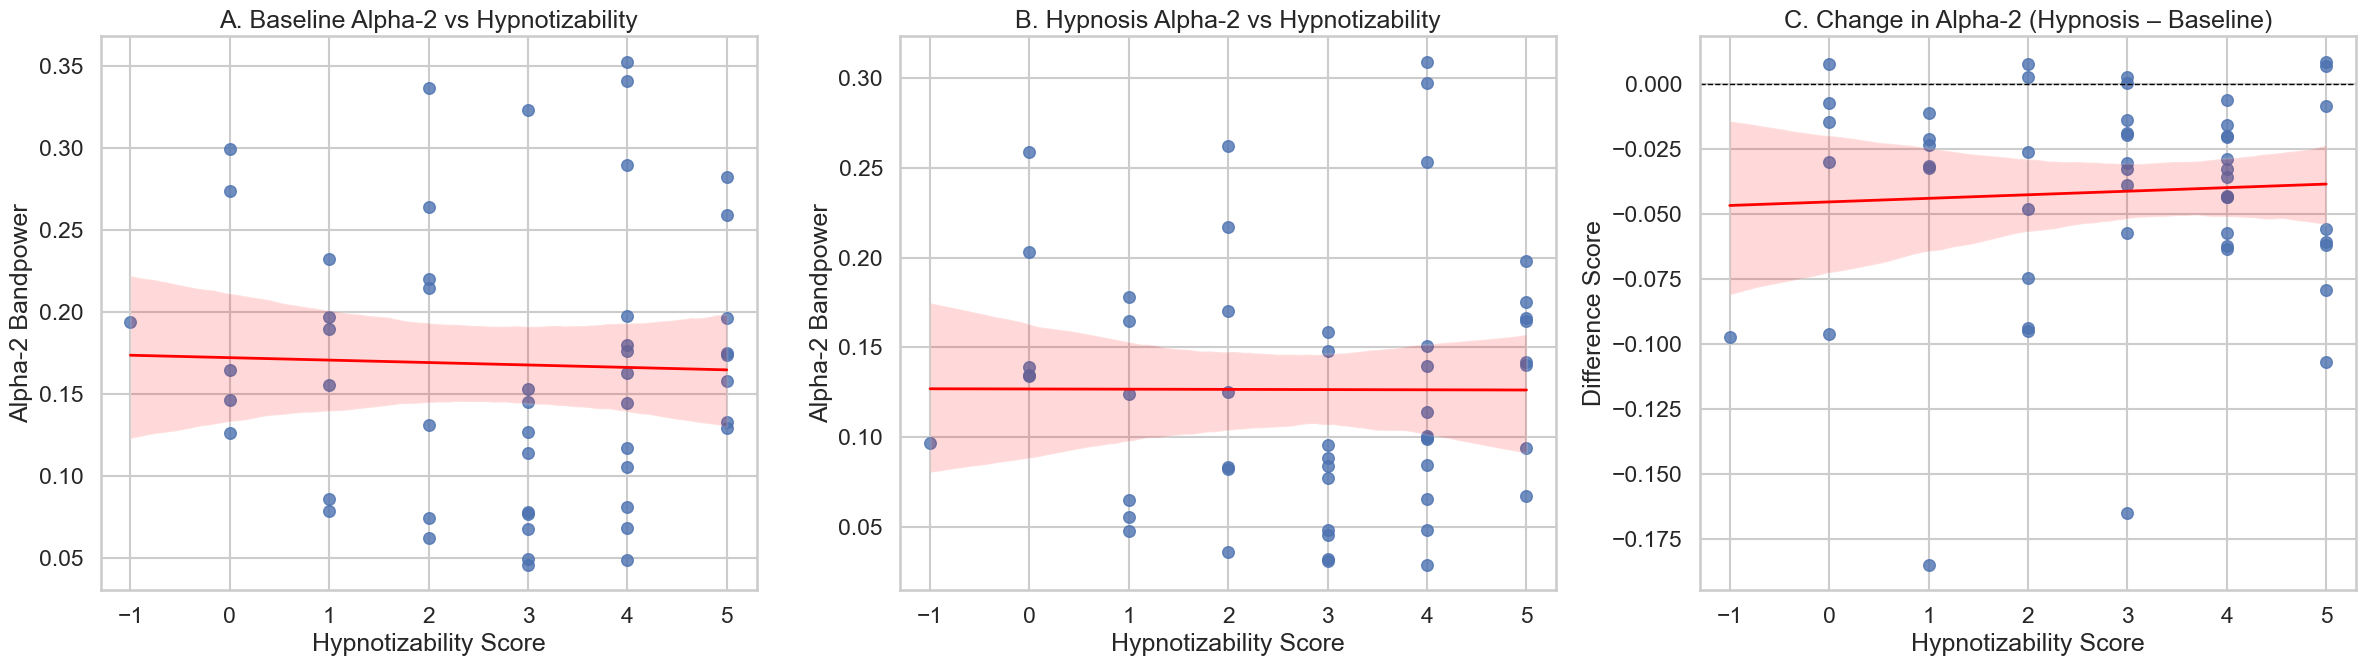

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")


# Set up figure
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# -------------------------
# Panel A — Baseline
# -------------------------
sns.regplot(
    x="hypnotizability_score",
    y="alpha2_baseline",
    data=wide_df,
    ax=axes[0],
    scatter_kws={"s": 70, "alpha": 0.8},
    line_kws={"color": "red", "linewidth": 2}
)
axes[0].set_title("A. Baseline Alpha-2 vs Hypnotizability")
axes[0].set_xlabel("Hypnotizability Score")
axes[0].set_ylabel("Alpha-2 Bandpower")

# -------------------------
# Panel B — Hypnosis
# -------------------------
sns.regplot(
    x="hypnotizability_score",
    y="alpha2_hypnosis",
    data=wide_df,
    ax=axes[1],
    scatter_kws={"s": 70, "alpha": 0.8},
    line_kws={"color": "red", "linewidth": 2}
)
axes[1].set_title("B. Hypnosis Alpha-2 vs Hypnotizability")
axes[1].set_xlabel("Hypnotizability Score")
axes[1].set_ylabel("Alpha-2 Bandpower")

# -------------------------
# Panel C — Difference Score
# -------------------------
sns.regplot(
    x="hypnotizability_score",
    y="alpha2_diff",
    data=wide_df,
    ax=axes[2],
    scatter_kws={"s": 70, "alpha": 0.8},
    line_kws={"color": "red", "linewidth": 2}
)
axes[2].set_title("C. Change in Alpha-2 (Hypnosis – Baseline)")
axes[2].set_xlabel("Hypnotizability Score")
axes[2].set_ylabel("Difference Score")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()
